In [178]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [179]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [180]:
paths = []
labels = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        paths.append(os.path.join(dirname,filename))
        label = filename.split('_')[-1]
        label = label.split('.')[0]
        labels.append(label.lower())
print("Dataset is Loaded")        
        


Dataset is Loaded


In [181]:
paths[:5]

['/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_youth_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_near_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_search_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_pick_fear.wav']

In [182]:
labels[:5]

['fear', 'fear', 'fear', 'fear', 'fear']

In [183]:
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels
df.head()

,speech,label
0,/kaggle/input/toronto-emotional-speech-set-tes...,fear
1,/kaggle/input/toronto-emotional-speech-set-tes...,fear
2,/kaggle/input/toronto-emotional-speech-set-tes...,fear
3,/kaggle/input/toronto-emotional-speech-set-tes...,fear
4,/kaggle/input/toronto-emotional-speech-set-tes...,fear


In [184]:
df['label'].value_counts()

label
fear       800
angry      800
disgust    800
neutral    800
sad        800
ps         800
happy      800
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

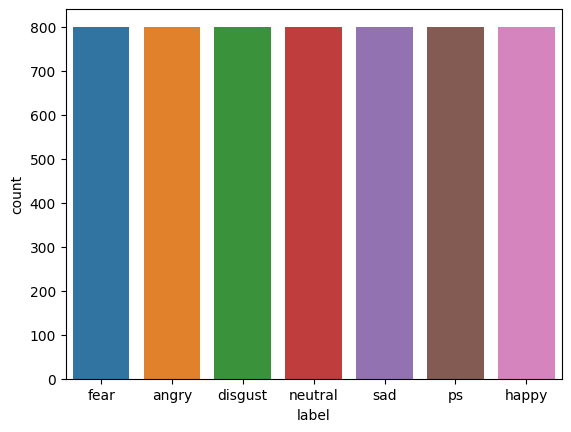

In [185]:
sns.countplot(x='label', data=df)


In [186]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveplot(data, sr=sr)
    plt.show()

def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time' , y_axis='hz')
    plt.colorbar()


    

In [187]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

def waveplot(data, sampling_rate, emotion):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(data, sr=sampling_rate)
    plt.title(f'Waveplot - {emotion}')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

def spectogram(data, sampling_rate, emotion):
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(np.abs(X))
    plt.figure(figsize=(11, 4))
    librosa.display.specshow(Xdb, sr=sampling_rate, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram - {emotion}')
    plt.tight_layout()
    plt.show()


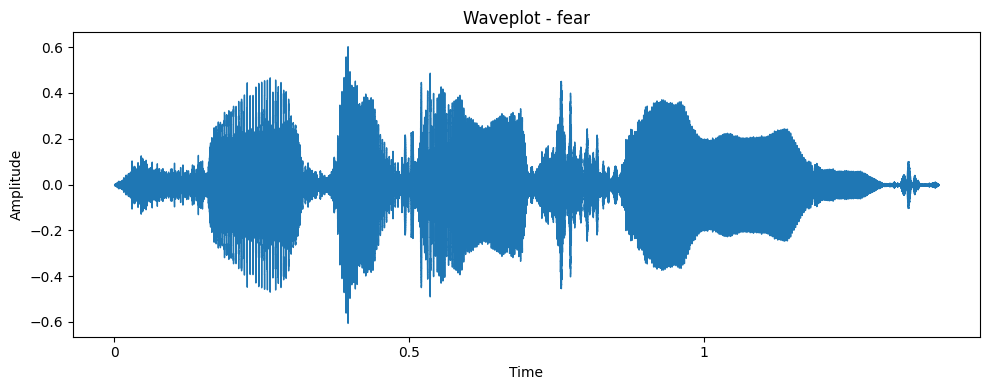

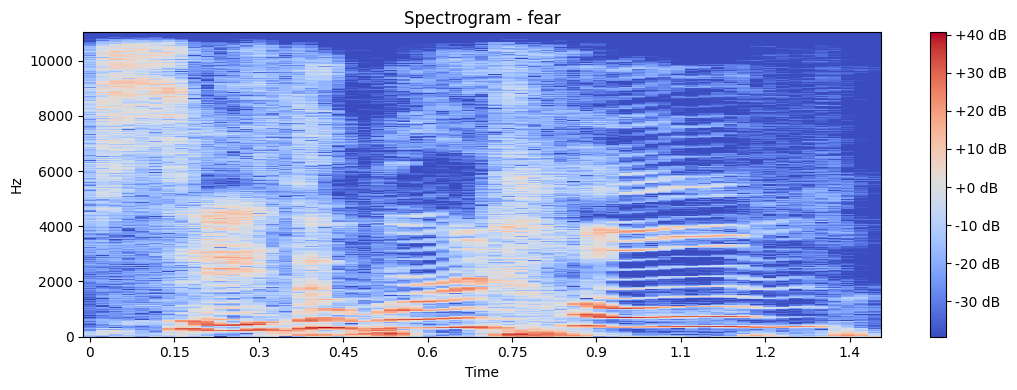

In [188]:
emotion = 'fear'
path = np.array(df['speech'][df['label'] == emotion])[0]
data, sampling_rate = librosa. load(path)
waveplot(data, sampling_rate, emotion)
spectogram( data, sampling_rate, emotion)
Audio(path)

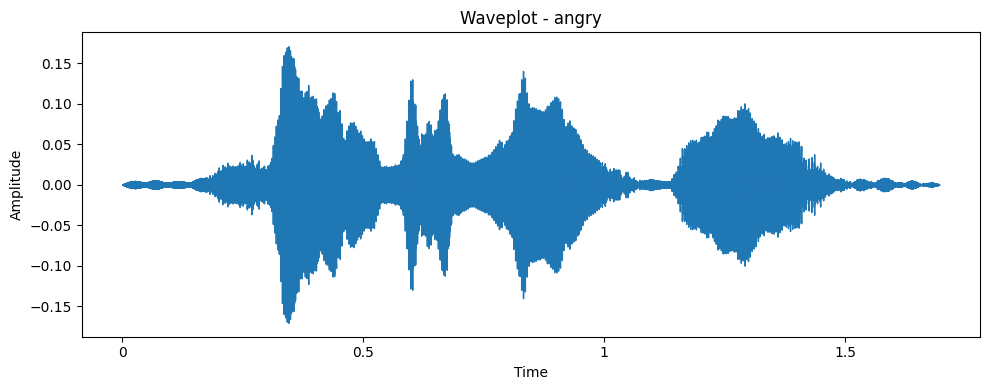

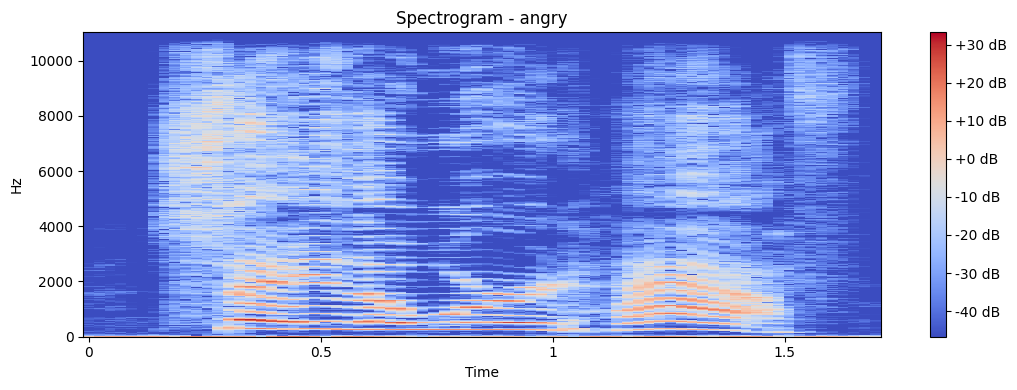

In [189]:
emotion = 'angry'
path = np.array(df['speech'][df['label'] == emotion])[1]
data, sampling_rate = librosa. load(path)
waveplot(data, sampling_rate, emotion)
spectogram( data, sampling_rate, emotion)
Audio(path)

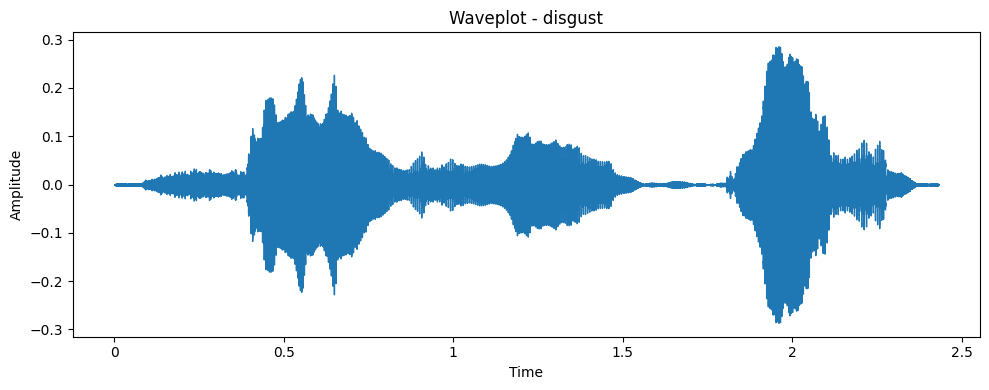

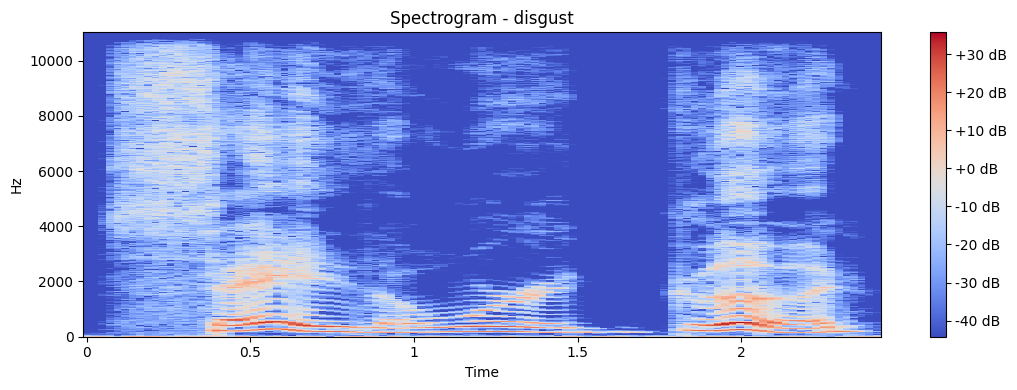

In [190]:
emotion = 'disgust'
path = np.array(df['speech'][df['label'] == emotion])[0]
data, sampling_rate = librosa. load(path)
waveplot(data, sampling_rate, emotion)
spectogram( data, sampling_rate, emotion)
Audio(path)

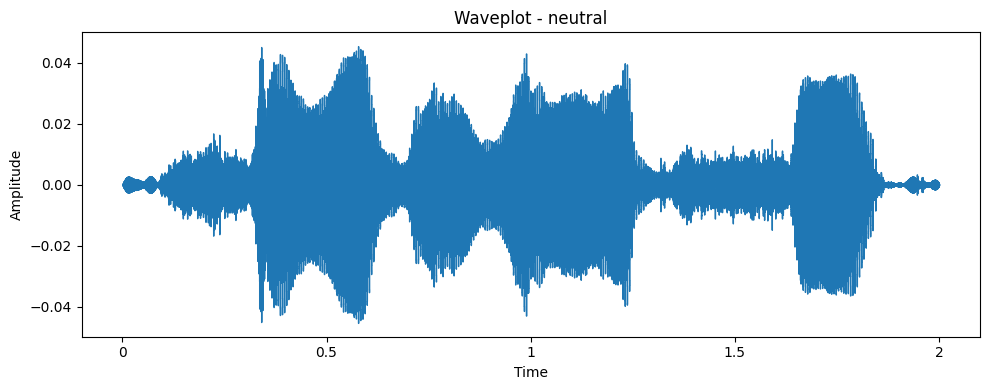

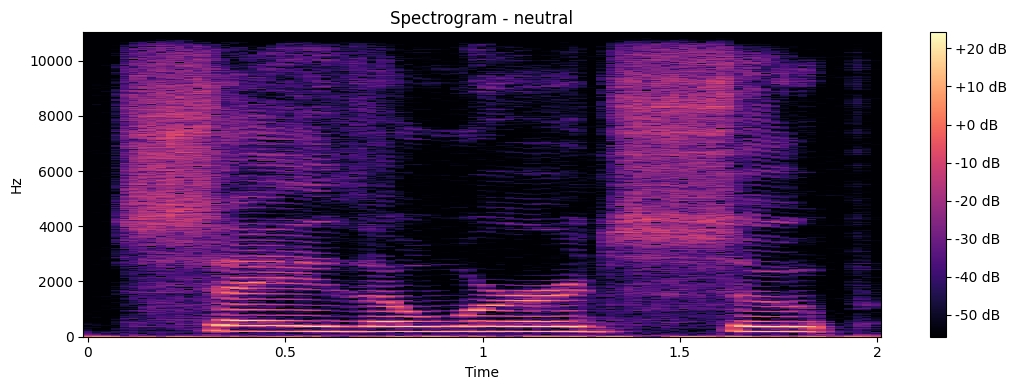

In [191]:
emotion = 'neutral'
path = np.array(df['speech'][df['label'] == emotion])[0]
data, sampling_rate = librosa. load(path)
waveplot(data, sampling_rate, emotion)
spectogram( data, sampling_rate, emotion)
Audio(path)

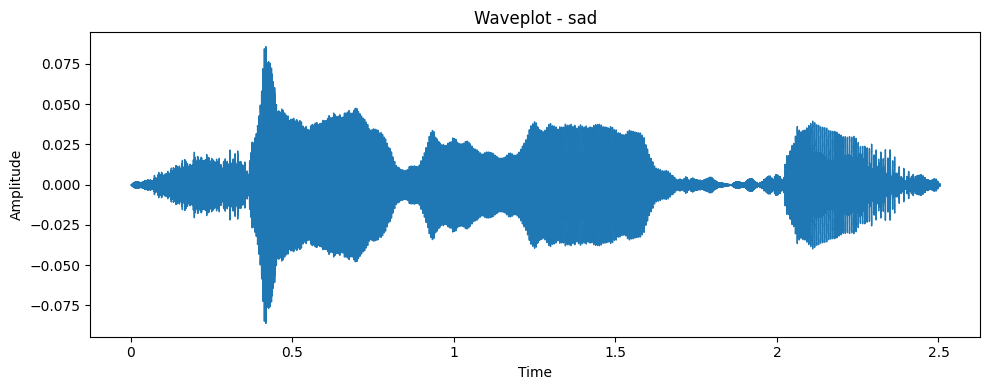

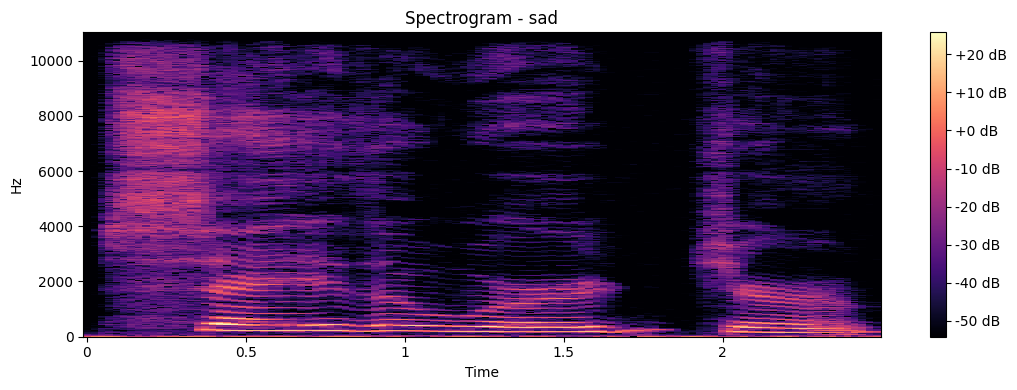

In [192]:
emotion = 'sad'
path = np.array(df['speech'][df['label'] == emotion])[0]
data, sampling_rate = librosa. load(path)
waveplot(data, sampling_rate, emotion)
spectogram( data, sampling_rate, emotion)
Audio(path)

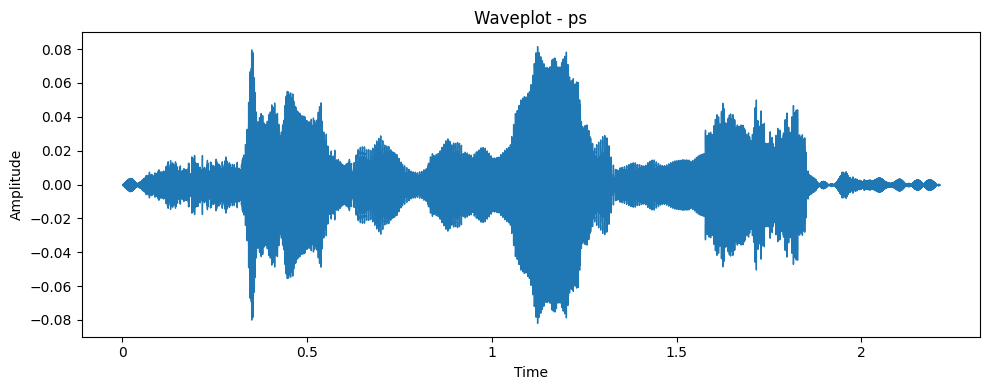

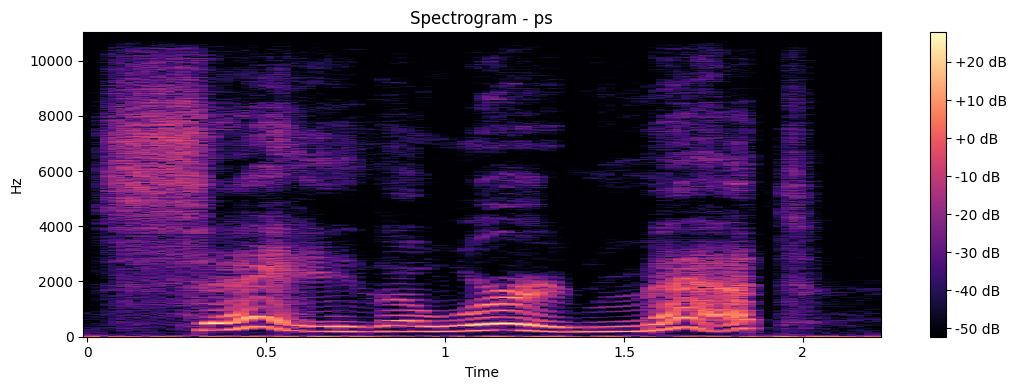

In [193]:
emotion = 'ps'
path = np.array(df['speech'][df['label'] == emotion])[0]
data, sampling_rate = librosa. load(path)
waveplot(data, sampling_rate, emotion)
spectogram( data, sampling_rate, emotion)
Audio(path)

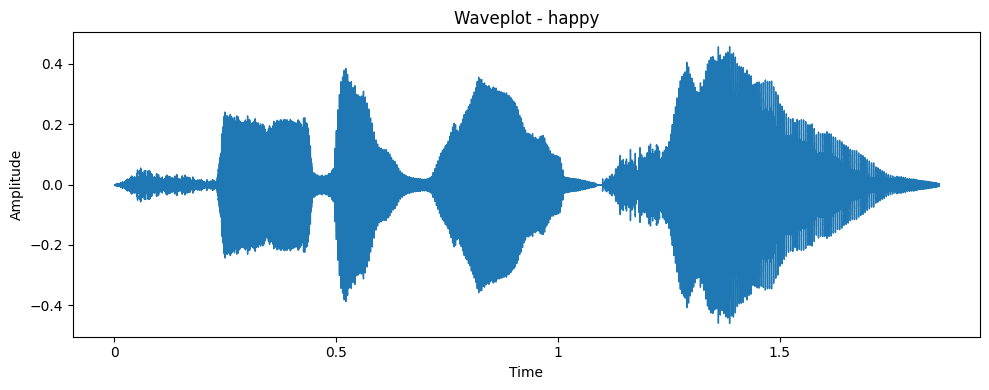

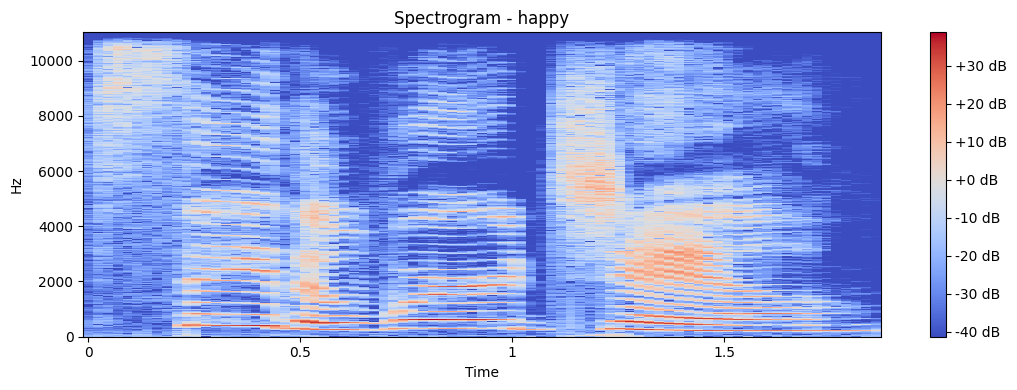

In [194]:
emotion = 'happy'
path = np.array(df['speech'][df['label'] == emotion])[0]
data, sampling_rate = librosa. load(path)
waveplot(data, sampling_rate, emotion)
spectogram( data, sampling_rate, emotion)
Audio(path)

In [195]:
def extract_mfcc(filename):
    y, sr = librosa. load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa. feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc


In [196]:
extract_mfcc(df['speech'][0])

array([-285.73727   ,   85.78295   ,   -2.1689117 ,   22.125532  ,
        -14.757396  ,   11.051346  ,   12.41245   ,   -3.000262  ,
          1.0844991 ,   11.078273  ,  -17.419657  ,   -8.093213  ,
          6.5879726 ,   -4.220953  ,   -9.155081  ,    3.5214806 ,
        -13.186381  ,   14.078853  ,   19.66973   ,   22.725618  ,
         32.574635  ,   16.325033  ,   -3.8427296 ,    0.89629626,
        -11.239264  ,    6.653462  ,   -2.5883694 ,   -7.714016  ,
        -10.941658  ,   -2.4007545 ,   -5.281286  ,    4.271157  ,
        -11.202216  ,   -9.024621  ,   -3.6669843 ,    4.8697433 ,
         -1.602798  ,    2.5600514 ,   11.454374  ,   11.233449  ],
      dtype=float32)

In [197]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))


In [198]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape


(5600, 40)

In [199]:
X = np.expand_dims(X, -1)
X.shape


(5600, 40, 1)

In [200]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])


In [201]:
y.toarray()

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [202]:
y.shape

(5600, 7)

In [203]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(123, return_sequences=False, input_shape=(40,1)),
    Dense(64, activation= 'relu'),
    Dropout(0.2),
    Dense(32, activation= 'relu' ),
    Dropout(0.2),
    Dense(7, activation= 'softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics = ['accuracy'])
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 123)                 │          61,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           7,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,747 (280.26 KB)

 Trainable params: 71,747 (280.26 KB)

 Non-trainable params: 0 (0.00 B)

In [204]:
from sklearn.preprocessing import OneHotEncoder

# Assuming df['label'] is your target variable
encoder = OneHotEncoder(sparse=False)  # Set sparse=False to get a dense array
y = encoder.fit_transform(df['label'].values.reshape(-1, 1))


In [205]:
import numpy as np

# Convert y to a numpy array if it's not already
y = np.array(y)


In [206]:
print(X.shape)  # Should be (num_samples, timesteps, features)
print(y.shape)  # Should be (num_samples, num_classes)

(5600, 40, 1)
(5600, 7)


In [207]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [208]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("First few samples of X:", X[:5])
print("First few samples of y:", y[:5])

X shape: (5600, 40, 1)
y shape: (5600, 7)
First few samples of X: [[[-2.85737274e+02]
  [ 8.57829514e+01]
  [-2.16891170e+00]
  [ 2.21255322e+01]
  [-1.47573957e+01]
  [ 1.10513458e+01]
  [ 1.24124498e+01]
  [-3.00026202e+00]
  [ 1.08449912e+00]
  [ 1.10782728e+01]
  [-1.74196568e+01]
  [-8.09321308e+00]
  [ 6.58797264e+00]
  [-4.22095299e+00]
  [-9.15508080e+00]
  [ 3.52148056e+00]
  [-1.31863813e+01]
  [ 1.40788527e+01]
  [ 1.96697292e+01]
  [ 2.27256184e+01]
  [ 3.25746346e+01]
  [ 1.63250332e+01]
  [-3.84272957e+00]
  [ 8.96296263e-01]
  [-1.12392635e+01]
  [ 6.65346193e+00]
  [-2.58836937e+00]
  [-7.71401596e+00]
  [-1.09416580e+01]
  [-2.40075445e+00]
  [-5.28128576e+00]
  [ 4.27115679e+00]
  [-1.12022161e+01]
  [-9.02462101e+00]
  [-3.66698432e+00]
  [ 4.86974335e+00]
  [-1.60279799e+00]
  [ 2.56005144e+00]
  [ 1.14543743e+01]
  [ 1.12334490e+01]]

 [[-3.48343323e+02]
  [ 3.51932335e+01]
  [-3.84132743e+00]
  [ 1.46588764e+01]
  [ 6.42105293e+00]
  [-7.73786545e-01]
  [-4.091442

In [209]:
history = model.fit(X, y, validation_split=0.2, epochs=100, batch_size=512, shuffle=True, verbose=1)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.2519 - loss: 1.9048 - val_accuracy: 0.1321 - val_loss: 2.0292
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4295 - loss: 1.5679 - val_accuracy: 0.1330 - val_loss: 1.7761
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5518 - loss: 1.2529 - val_accuracy: 0.2027 - val_loss: 1.4923
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6775 - loss: 0.8961 - val_accuracy: 0.5321 - val_loss: 1.1311
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7491 - loss: 0.6665 - val_accuracy: 0.7098 - val_loss: 0.7690
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8308 - loss: 0.4785 - val_accuracy: 0.7330 - val_loss: 0.6588
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8466 - loss: 0.4257 - val_accuracy: 0.7839 - val_loss: 0.5676
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8787 - loss: 0.3403 - val_accuracy: 0.8821 - val_loss:

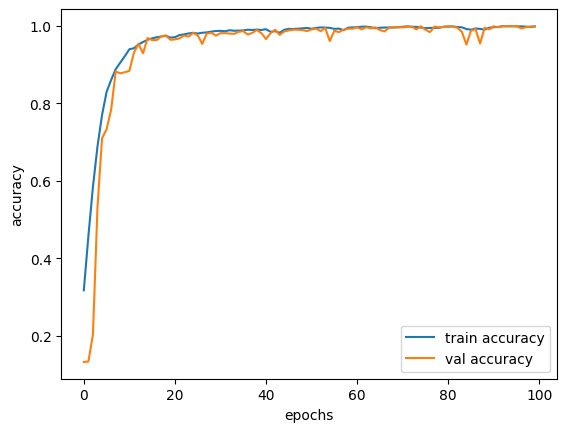

In [210]:
epochs = list(range(100))
acc = history.history['accuracy'] 
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, label= 'train accuracy')
plt.plot(epochs, val_acc, label= 'val accuracy')
plt.xlabel( 'epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()


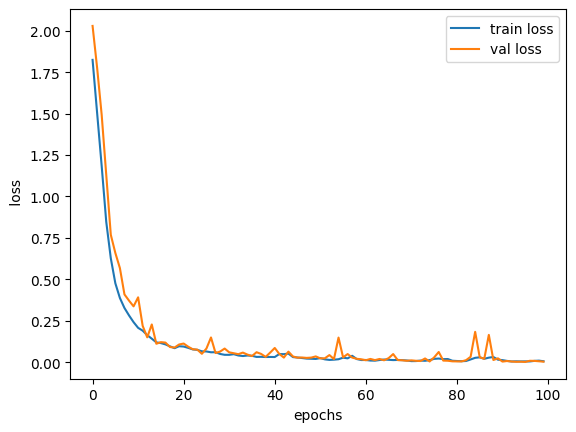

In [211]:
loss = history.history['loss']
val_loss =  history.history['val_loss']
plt.plot(epochs, loss, label= 'train loss')
plt.plot(epochs, val_loss, label= 'val loss')
plt.xlabel('epochs')
plt.ylabel(' loss')
plt.legend()
plt.show()
